In [11]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 모터사이클, 야구, 그래픽스, 윈도우즈, 중동, 기독교, 전자공학, 의학 8개 주제를 추출.
cats = ['rec.motorcycles', 'rec.sport.baseball', 'comp.graphics', 'comp.windows.x',
        'talk.politics.mideast', 'soc.religion.christian', 'sci.electronics', 'sci.med']

# 위에서 cats 변수로 기재된 카테고리만 추출. featch_20newsgroups( )의 categories에 cats 입력
news_df= fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'),
                            categories=cats, random_state=0)
# LDA는 Count 기반의 벡터화만 적용합니다.
count_vect = CountVectorizer(max_df=0.95, max_features=1000, min_df=2, stop_words='english',
                             ngram_range=(1, 2))
feat_vect = count_vect.fit_transform(news_df.data)
print('CountVectorizer Shape:', feat_vect.shape)

CountVectorizer Shape: (7862, 1000)


In [12]:
lda = LatentDirichletAllocation(n_components=8, random_state=0)
lda.fit(feat_vect)

LatentDirichletAllocation(n_components=8, random_state=0)

In [13]:
Ida = LatentDirichletAllocation(n_components=8, random_state=0)
Ida.fit(feat_vect)

print(Ida.components_.shape)
Ida.components_

(8, 1000)


array([[2.69030238e+02, 1.87798026e+02, 7.09003824e+01, ...,
        1.22710343e+01, 1.06329639e+02, 7.25995512e+01],
       [1.25091799e-01, 2.46049106e+00, 1.25051902e-01, ...,
        2.80071176e+02, 1.25089783e-01, 5.05669662e+01],
       [1.33978420e+02, 1.25042012e-01, 9.98277256e+01, ...,
        1.25092219e-01, 3.31078261e+01, 1.25028398e-01],
       ...,
       [2.98813886e+01, 1.88071366e+01, 1.14748730e+01, ...,
        1.93022584e+01, 5.29368271e+00, 1.44478198e+01],
       [1.25074899e-01, 1.25105300e-01, 1.25004235e-01, ...,
        1.03576436e+02, 1.25100535e-01, 7.22276359e+01],
       [1.25172284e-01, 1.03967760e+00, 1.25221075e-01, ...,
        5.31740996e+01, 1.25025929e-01, 1.25062991e-01]])

In [14]:
def display_topics(model, feature_names, no_top_words):
  for topic_index, topic in enumerate(model.components_):
    print('Topic #', topic_index)
    # components, array에서 가장 값이 큰 순으로 정렬했을 때, 그 값의 array 인덱스를 반환.
    topic_word_indexes = topic.argsort()[::-1 ]
    top_indexes=topic_word_indexes[:no_top_words]

    # top_indexes대상인 인덱스별로 feature_names에 해당하는 word feature 추출 후 join으로 concat
    feature_concat = ' '.join([feature_names[i] for i in top_indexes])
    print(feature_concat)

# CountVectorizer 객체 내의 전체 word의 명칭을 get_features_names( )를 통해 추출
feature_names = count_vect.get_feature_names_out()
# 토픽별 가장 연관도가 높은 word를 15개만 추출
display_topics(lda, feature_names, 15)

Topic # 0
10 year medical health 1993 20 12 disease cancer team patients research number new 11
Topic # 1
don just like know think good time ve does way really people want ll right
Topic # 2
image file jpeg output program gif images format files color entry use bit 03 02
Topic # 3
armenian armenians turkish people said turkey armenia government genocide turks muslim russian greek azerbaijan killed
Topic # 4
israel jews dos jewish israeli dos dos arab state people arabs palestinian adl ed anti peace
Topic # 5
edu com available graphics ftp window use mail data motif software version pub information server
Topic # 6
god people jesus church believe say christ does christian think christians did know bible man
Topic # 7
thanks use using does help like display need problem know server screen windows window program


In [15]:
import pandas as pd
import glob, os
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 700)

# 다음은 저자의 컴퓨터에서 압축 파일을 풀어놓은 디렉터리이니, 각자 디렉터리를 다시 설정합니다.
path = r'C:\Users\parkn\OneDrive\바탕 화면'
# path로 지정한 디렉터리 밑에 있는 모든 .data 파일들의 파일명을 리스트로 취합
all_files = glob.glob(os.path.join(path, "*.data"))
filename_list = [ ]
opinion_text = []

# 개별 파일들의 파일명은 filename_list 리스트로 취합,
# 개별 파일들의 파일 내용은 DataFrame 로딩 후 다시 string으로 변환하여 opinion_text 리스트로 취합
for file_ in all_files:
  # 개별 파일을 읽어서 DataFrame으로 생성
  df = pd.read_table(file_, index_col=None, header=0, encoding='latin1')
  # 절대경로로 주어진 파일명을 가공. Linux에서 수행 시에는 아래 \\를 / 변경.
  # 맨 마지막 .data 확장자도 제거
  filename_= file_.split('\\')[-1]
  filename = filename_.split('.')[0]

  # 파일명 리스트와 파일 내용 리스트에 파일명과 파일 내용을 추가.
  filename_list.append(filename)
  opinion_text.append(df.to_string())

# 파일명 리스트와 파일 내용 리스트를 DataFrame으로 생성
document_df = pd.DataFrame({'filename':filename_list, 'opinion_text':opinion_text})
document_df.head()

,filename,opinion_text


In [16]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string

lemmatizer = WordNetLemmatizer()

def LemNormalize(text):
    remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)
    return [
        lemmatizer.lemmatize(token.lower())
        for token in word_tokenize(text.translate(remove_punct_dict))
    ]

In [17]:
import glob

data_files = glob.glob("/content/*.txt.data")
print(len(data_files))
print(data_files[:5])


51
['/content/quality_toyota_camry_2007.txt.data', '/content/service_swissotel_hotel_chicago.txt.data', '/content/speed_garmin_nuvi_255W_gps.txt.data', '/content/service_bestwestern_hotel_sfo.txt.data', '/content/screen_netbook_1005ha.txt.data']


In [18]:
documents = []

for file in data_files:
    with open(file, 'r', encoding='latin-1') as f:
        documents.append(f.read())

print(len(documents))
print(documents[0][:300])


51
 I previously owned a Toyota 4Runner which had incredible build quality and reliability .
I bought the Camry because of Toyota reliability and quality .
I purchased a 2007 Camry because of the looks of the redesigned model and because of the  legendary  Toyota quality and reliability .
 As of today,


In [19]:
import pandas as pd

document_df = pd.DataFrame({
    "opinion_text": documents
})

document_df.head()


,opinion_text
0,"I previously owned a Toyota 4Runner which had incredible build quality and reliability .\nI bought the Camry because of Toyota reliability and quality .\nI purchased a 2007 Camry because of the looks of the redesigned model and because of the legendary Toyota quality and reliability .\n As of today, I am a bit disappointed in the build quality of the car .\n Disappointed in interior and exterior quality .\n Toyota did a great job with design but forgot about quality !\n This car needs quality improvement !\n The fit and finish in the cabin is not the level of quality I expected .\nThis car looks great and the build quality is good .\n I am so disappointed in the quality .\nI've had 2 ..."
1,"Mediocre room and service for a very extravagant price .\n The accomodations and support services are phenomenal .\n no robes in the rooms, ice machines are not on every floor , no turn down service at night, and when housekeeping did come, they did not replace the shower gel we had used which was totally empty .\nConcierge service was fine when we needed our boarding pass printed .\n Room service was expensive in the hotel .\n Even with the amount we saved on the room, we could not justify spending the amount they listed for room service .\nClose to everything , underground eating, Michigan avenue shops , walking or short cabNegatives, Room service expensive , ridiculously expensi..."
2,"Another feature on the 255w is a display of the posted speed limit on the road which you are currently on right above your current displayed speed .\n I found myself not even looking at my car speedometer as I could easily see my current speed and the speed limit of my route at a glance .\nMy final decision was to keep the 255w and return the 750 because I really liked the graphic turn indicator and the posted speed limit and current speed indicators .\n It even tells you the speed limit on most roads .\n The new display posts speed limit signs of major roads flush left on the screen, which is a new feature that is also really helpful, if you're driving in an unfamiliar area .\n Display ..."
3,"Both of us having worked in tourism for over 14 years were very disappointed at the level of service provided by this gentleman .\n The service was good, very friendly staff and we loved the free wine reception each night .\n Also, thanks to Ken the concierge for recommending Grand Limo service .\n The restaurant is not cheap but is very well patronised and the service is very good as is the food .\n Service was spotty Front desk was marginally helpful .\n This tuscan, themed hotel was charming, clean comfortable and the complimentary concierge service was so helpful .\nPhenominal Service, great room, great location , couldn't have asked for more .\n It has some charms in decor, and..."
4,"Keep in mind that once you get in a room full of light or step outdoors screen reflections could become annoying .\n I've used mine outside on a sunny day, and the screen is still very much legible .\n In fact it was much more detailed than the matte screen on my Dell D600 .\n Some ppl may prefer a higher resolution screen but I don't think it's required .\n I delayed ordering the computer because of the horror stories of bad batteries, faulty chargers and blue screen crashes .\n1 inch screens, Windows XP operating systems, a plethora of USB ports, a card reader, WiFi and most have a few color choices .\n1 inch screens are a bit cramped if several toolbars have been turned on .\n Some o..."


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=1,
    max_df=0.95
)

X = tfidf_vect.fit_transform(
    document_df["opinion_text"].fillna("").astype(str)
)

print(X.shape)


(51, 47801)


In [21]:
print(document_df.head())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  opinion_text
0   I previously owned a Toyota 4Runner which had incredible build quality and reliability .\nI bought the Camry because of Toyota reliability and quality .\nI purchased a 2007 Camry because of the looks of the redesigned model and because of the  legendary  Toyota quality and reliability .\n As 

In [22]:
import nltk
import string
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

In [23]:
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [24]:
lemmatizer = WordNetLemmatizer()

def LemNormalize(text):
    tokens = nltk.word_tokenize(text.lower())
    return [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in string.punctuation
    ]

In [25]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(
    tokenizer=LemNormalize,
    stop_words='english',
    ngram_range=(1,2),
    min_df=0.05,
    max_df=0.85
)

feature_vect = tfidf_vect.fit_transform(
    document_df['opinion_text']
)

print(feature_vect.shape)


(51, 4484)


In [27]:
from sklearn.cluster import KMeans
# 5개 집합으로 군집화 수행. 예제를 위해 동일한 클러스터링 결과 도출용 random_state게
km_cluster = KMeans(n_clusters=5, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
cluster_centers = km_cluster.cluster_centers_

In [28]:
document_df['cluster_label'] = cluster_label
document_df.head()

,opinion_text,cluster_label
0,"I previously owned a Toyota 4Runner which had incredible build quality and reliability .\nI bought the Camry because of Toyota reliability and quality .\nI purchased a 2007 Camry because of the looks of the redesigned model and because of the legendary Toyota quality and reliability .\n As of today, I am a bit disappointed in the build quality of the car .\n Disappointed in interior and exterior quality .\n Toyota did a great job with design but forgot about quality !\n This car needs quality improvement !\n The fit and finish in the cabin is not the level of quality I expected .\nThis car looks great and the build quality is good .\n I am so disappointed in the quality .\nI've had 2 ...",2
1,"Mediocre room and service for a very extravagant price .\n The accomodations and support services are phenomenal .\n no robes in the rooms, ice machines are not on every floor , no turn down service at night, and when housekeeping did come, they did not replace the shower gel we had used which was totally empty .\nConcierge service was fine when we needed our boarding pass printed .\n Room service was expensive in the hotel .\n Even with the amount we saved on the room, we could not justify spending the amount they listed for room service .\nClose to everything , underground eating, Michigan avenue shops , walking or short cabNegatives, Room service expensive , ridiculously expensi...",3
2,"Another feature on the 255w is a display of the posted speed limit on the road which you are currently on right above your current displayed speed .\n I found myself not even looking at my car speedometer as I could easily see my current speed and the speed limit of my route at a glance .\nMy final decision was to keep the 255w and return the 750 because I really liked the graphic turn indicator and the posted speed limit and current speed indicators .\n It even tells you the speed limit on most roads .\n The new display posts speed limit signs of major roads flush left on the screen, which is a new feature that is also really helpful, if you're driving in an unfamiliar area .\n Display ...",0
3,"Both of us having worked in tourism for over 14 years were very disappointed at the level of service provided by this gentleman .\n The service was good, very friendly staff and we loved the free wine reception each night .\n Also, thanks to Ken the concierge for recommending Grand Limo service .\n The restaurant is not cheap but is very well patronised and the service is very good as is the food .\n Service was spotty Front desk was marginally helpful .\n This tuscan, themed hotel was charming, clean comfortable and the complimentary concierge service was so helpful .\nPhenominal Service, great room, great location , couldn't have asked for more .\n It has some charms in decor, and...",3
4,"Keep in mind that once you get in a room full of light or step outdoors screen reflections could become annoying .\n I've used mine outside on a sunny day, and the screen is still very much legible .\n In fact it was much more detailed than the matte screen on my Dell D600 .\n Some ppl may prefer a higher resolution screen but I don't think it's required .\n I delayed ordering the computer because of the horror stories of bad batteries, faulty chargers and blue screen crashes .\n1 inch screens, Windows XP operating systems, a plethora of USB ports, a card reader, WiFi and most have a few color choices .\n1 inch screens are a bit cramped if several toolbars have been turned on .\n Some o...",1


In [29]:
import os
import pandas as pd

document_df = pd.DataFrame({
    "filename": [os.path.basename(f) for f in data_files],
    "opinion_text": documents
})

In [30]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(feature_vect)

In [31]:
document_df['cluster_label'] = cluster_labels

In [32]:
document_df [document_df ['cluster_label']==0] .sort_values(by='filename')

,filename,opinion_text,cluster_label
48,bathroom_bestwestern_hotel_sfo.txt.data,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n Large comfortable room, wonderful bathroom .\n The rooms were nice, very comfy bed and very clean bathroom .\n Bathroom was spacious too and very clean .\n The bathroom only had a single sink, but it was very large .\n The room was a standard but nice motel room like any other, bathroom seemed upgraded if I remember .\nThe room was quite small but perfectly formed with a super bathroom .\n You could eat off the bathroom floor it was so clean .\n The ba...",0
44,comfort_honda_accord_2008.txt.data,"Drivers seat not comfortable, the car itself compared to other models of similar class .\n It's very comfortable, remarkably large inside and just an overall great vehicle .\n Front seats are very uncomfortable .\n I'm 6' tall, and find the driving position pretty comfortable .\n However, there are a couple of things that kill it for me 1 terrible driver seat comfort, kills my back 2 lack luster interior design, my Acadia has much better comfort 3 the VCM drives me crazy because the constant change in cylinder use is perceptible enough to be an annoyance .\n The seats are extremely uncomfortable .\n While the Accord is no Acura it is a close relative in terms of quality and comfort .\n ...",0
29,comfort_toyota_camry_2007.txt.data,"Ride seems comfortable and gas mileage fairly good averaging 26 city and 30 open road .\n Seats are fine, in fact of all the smaller sedans this is the most comfortable I found for the price as I am 6', 2 and 250# .\n Great gas mileage and comfortable on long trips .\n Good gas mileage, comfortable seating, lots of leg room .\n Lots of comfort for the price .\n The ride is loud and not comfortable .\n I drive 2 hours to work each day and it is just not comfortable to me .\n Getting about 26 mpg mixed city hwy with conservative driving, seating 4 people comfortably .\n The ride is quiet and comfortable .\n Styling is bland, the engine isn't strong at all, and the car doesn't deliver goo...",0
17,food_holiday_inn_london.txt.data,"The room was packed to capacity with queues at the food buffets .\n The over zealous staff cleared our unfinished drinks while we were collecting cooked food and movement around the room with plates was difficult in the crowded circumstances .\n There are a couple pubs, a great patisserie and even fast food restaurants within a block .\nThe neighborhood is an upscale residential area full of restaurants in easy walking distance ranging from fast food to up, scale with a wide variety of cuisines , , we never had a bad meal .\nThe food was wonderful, a selection of sandwiches, salads, cous cous and spicy wedge potato's, fruit salad and a cake was a good fill up when needed .\nFull ...",0
15,food_swissotel_chicago.txt.data,"The food for our event was delicious .\n The food in the lounge was great and very fresh, , , salads, sandwiches etc .\n As far as food, walk a few blocks toward Michigan Ave turn left or right and there are plently of less expensive places to eat .\n The Palm resturant in the hotel had some specials Sunday night, we ate there and the food service,etc were outstanding portions are large and we shared since we are not big eaters .\n Took the charge of the minibar which we had used to keep my 2 year old sons food .\n We never ate anything onsite so I can't vouch for the food options immediately avialable .\n The Lobby bar does not serve food very late at night and we couldn't find any ven...",0
47,gas_mileage_toyota_camry_2007.txt.data,"Ride seems comfortable and gas mileage fairly good averaging 26 city and 30 open road .\n It gets great gas mileage .\n Being a mother who drives a lot I wanted a safe vehicle with good gas mileage and this car delivered th

In [33]:
document_df [document_df ['cluster_label']==1 ].sort_values(by='filename')

,filename,opinion_text,cluster_label
10,accuracy_garmin_nuvi_255W_gps.txt.data,", and is very, very accurate .\n but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n This function is not accurate if you don't leave it in battery mode say, when you stop at the Cracker Barrell for lunch and to play one of those trangle games with the tees .\n It provides immediate alternatives if the route from the online map program was inaccurate or blocked by an obstacle .\n I've used other GPS units, as well as GPS built into cars and to this day NOTHING beats the accuracy of a Garmin GPS .\n It got me from point A to point B with 100% accuracy everytime .\n It has yet to disappoint, getting me everywhere with 100% a...",1
28,battery-life_amazon_kindle.txt.data,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there !\n NO USER REPLACEABLE BATTERY, , Unless you buy the extended warranty for $65 .\n After 1 year you pay $80 plus shipping to send the device to Amazon and have the Kindle REPLACED, not the battery changed out .\nThe fact that Kindle 2 has no SD card capability and the battery is not user, serviceable is not an issue with me .\n Things like the buttons that made it easy to accidentally tur...",1
20,battery-life_ipod_nano_8gb.txt.data,"short battery life I moved up from an 8gb .\nI love this ipod except for the battery life .\n long battery scratch resistant\n Battery drains even if I don't use it .\n I only wonder why the battery seems to drain when I'm not using it, even after sliding the top control button to off when shutting down .\n great in the car, light, portable, good quality, long battery,scratch resistant .\n5G lies a more mature iPod, many steps wiser and more able than its one, year, old The iPod gains many incremental improvements, including a brighter screen and better video battery life, but probably the most appealing aspect is the tantalizing price points of $249 for the 30GB version and $349 for...",1
49,battery-life_netbook_1005ha.txt.data,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 .\n Not to mention that as of now Asus will not sell you a spare 3 or 6, cell Li, Ion battery .\n It also features a N270 cpu, 6, cell 48Wh Li, ion Battery 8 .\n3MP webcam, 6, Cell 63Wh Li, ion Battery with a whopping 10 .\n Realistic battery numbers are between 8 .\n of battery life if you're using wifi & doing email word processing YouTube web surfing .\n The Eee Super Hybrid Engine utility lets users overclock or underclock their Eee PC's to boost performance or provide better battery life depending on their immediate requirements .\n A few other things I'd like to point out is that you must push the micro, sized...",1
35,features_windows7.txt.data,"I had to uninstall anti, virus and selected other programs, some of which did not have listings in the Programs and Features Control Panel section .\n This review briefly touches upon some of the key features and enhancements of Microsoft's latest OS .\n All of these features combine to create a much improved and enjoyable desktop experience .\nI enjoyed the new convenience features in Windows 7 .\n They showed me PC laptops that had more features than the MacBook, and which cost way less than the MacBook, too .\n But that aside, I like the availability of software, the new features like the improved Taskbar, Windows Peek, and the Aero environment .\nIf you're used to OS X, but want t...",1
22,free_bestwestern_hotel_sfo.txt.data,"The wine reception is a great idea as it is nice to meet other travellers and great having access to the free Internet access in our room .\n They also have a computer available with free internet which is a nice bonus but I d

In [34]:
document_df[document_df['cluster_label']==2].sort_values(by='filename')

,filename,opinion_text,cluster_label
21,buttons_amazon_kindle.txt.data,"I thought it would be fitting to christen my Kindle with the Stephen King novella UR, so went to the Amazon site on my computer and clicked on the button to buy it .\n As soon as I'd clicked the button to confirm my order it appeared on my Kindle almost immediately !\nAfter reading through the introductory guide that loads up automatically at the start and following along it took me almost no time to learn which buttons are where and what each of them do .\n I started reading with the default size without my glasses and noticed I was squinting a bit, so changed to one size larger with a couple button clicks and it was much easier without feeling like the print was too big and took up too...",2
23,directions_garmin_nuvi_255W_gps.txt.data,"You also get upscale features like spoken directions including street names and programmable POIs .\n I used to hesitate to go out of my directions but not any more .\n the directions didn't tell me anything I didn't already know after fiddling with it for 10 minutes .\n It also does not offer an option to view the route as a series of turn by turn directions .\n It gives your heading not in terms of degres but only in terms of one of eight directions .\nThe widescreen is a plus and I highly recommend it, even though it has the wide screen you can stick it in your back pocket which can be conveniently used for walking directions .\nGarmin's nuvi 255W is a handy little device that pr...",2
11,display_garmin_nuvi_255W_gps.txt.data,"3 quot widescreen display was a bonus .\n This made for smoother graphics on the 255w of the vehicle moving along displayed roads, where the 750's display was more of a jerky movement .\n I also found that the display on the 255w was a bit brighter, clearer, and more vivid than on the 750 in both daylight and at night .\n The 750 just displays text on the top line for upcoming turns without the arrow .\n The 255 also automatically adjusts the font size of displayed text so that even lengthy text will fit .\nAnother feature on the 255w is a display of the posted speed limit on the road which you are currently on right above your current displayed speed .\nThe 255W has a really clear di...",2
7,eyesight-issues_amazon_kindle.txt.data,"It feels as easy to read as the K1 but doesn't seem any crisper to my eyes .\n the white is really GREY, and to avoid considerable eye, strain I had to refresh pages every other page .\n The dream has always been a portable electronic device that could hold a ton of reading material, automate subscriptions and facilitate quick easy downloads, and be as portable, as easy on the eyes, and as intuitive as a book .\n they would ask, to which I would squint my eyes and reply, Huh ?\n I found that the Kindle 2 is immediately appealing to the eye and once described in the barest of terms people want one for themselves .\n No having to turn away every few minutes to relax your eyes or en...",2
5,fonts_amazon_kindle.txt.data,"Being able to change the font sizes is awesome !\n For whatever reason, Amazon decided to make the Font on the Home Screen than on the K1 .\n I found myself constantly changing the angle of the body, changing the font size up and down and the distance away from me .\n I was an avid reader but increasing age has made printed books more of a challenge, but the Kindle with its varying font size and very light weight has made reading fun again .\n What's more, it's easy to change font size .\n The kindle does not recognize page numbers, since they would change radically when you change font size so Amazon provides the notion of location which is display independent .\n I just crank the fo...",2
46,navigation_amazon_kindle.txt.data,"In fact, the entire navigation structure has been completely revised , I'm still getting used to it but it's a huge step forward .\nNavigation is a huge improvement .\n Clearly, Amazon was hard at work to make navigation quicker and 

In [35]:
document_df[document_df['cluster_label']==3].sort_values(by='filename')

,filename,opinion_text,cluster_label


In [36]:
document_df[document_df['cluster_label']==4].sort_values(by='filename')

,filename,opinion_text,cluster_label


In [37]:
from sklearn.cluster import KMeans
# 3개의 집합으로 군집화
km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
# 소속 클러스터를 cl니ster_label 칼럼으로 할당하고 cluster_label 값으로 정렬
document_df ['cluster_label'] = cluster_label
document_df.sort_values(by='cluster_label')

,filename,opinion_text,cluster_label
2,speed_garmin_nuvi_255W_gps.txt.data,"Another feature on the 255w is a display of the posted speed limit on the road which you are currently on right above your current displayed speed .\n I found myself not even looking at my car speedometer as I could easily see my current speed and the speed limit of my route at a glance .\nMy final decision was to keep the 255w and return the 750 because I really liked the graphic turn indicator and the posted speed limit and current speed indicators .\n It even tells you the speed limit on most roads .\n The new display posts speed limit signs of major roads flush left on the screen, which is a new feature that is also really helpful, if you're driving in an unfamiliar area .\n Display ...",0
15,food_swissotel_chicago.txt.data,"The food for our event was delicious .\n The food in the lounge was great and very fresh, , , salads, sandwiches etc .\n As far as food, walk a few blocks toward Michigan Ave turn left or right and there are plently of less expensive places to eat .\n The Palm resturant in the hotel had some specials Sunday night, we ate there and the food service,etc were outstanding portions are large and we shared since we are not big eaters .\n Took the charge of the minibar which we had used to keep my 2 year old sons food .\n We never ate anything onsite so I can't vouch for the food options immediately avialable .\n The Lobby bar does not serve food very late at night and we couldn't find any ven...",0
10,accuracy_garmin_nuvi_255W_gps.txt.data,", and is very, very accurate .\n but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n This function is not accurate if you don't leave it in battery mode say, when you stop at the Cracker Barrell for lunch and to play one of those trangle games with the tees .\n It provides immediate alternatives if the route from the online map program was inaccurate or blocked by an obstacle .\n I've used other GPS units, as well as GPS built into cars and to this day NOTHING beats the accuracy of a Garmin GPS .\n It got me from point A to point B with 100% accuracy everytime .\n It has yet to disappoint, getting me everywhere with 100% a...",0
11,display_garmin_nuvi_255W_gps.txt.data,"3 quot widescreen display was a bonus .\n This made for smoother graphics on the 255w of the vehicle moving along displayed roads, where the 750's display was more of a jerky movement .\n I also found that the display on the 255w was a bit brighter, clearer, and more vivid than on the 750 in both daylight and at night .\n The 750 just displays text on the top line for upcoming turns without the arrow .\n The 255 also automatically adjusts the font size of displayed text so that even lengthy text will fit .\nAnother feature on the 255w is a display of the posted speed limit on the road which you are currently on right above your current displayed speed .\nThe 255W has a really clear di...",0
12,location_holiday_inn_london.txt.data,"Great location for tube and we crammed in a fair amount of sightseeing in a short time .\nAll in all, a normal chain hotel on a nice location , I will be back if I do not find anthing closer to Picadilly for a better price .\nGreat Price Terrific Location .\nThe location is absolutely wonderful .\nOur main focus before booking was looking for a low price with good location .\nVery Good Value , Excellent Location .\n The location is ideal for travel all over the city via the Underground .\nExcellent hotel in prime location .\nGood Location Horrible Service Disgusting Procedures .\nFirst and foremost, the good, yes it has good location, a block away from Gloucester Road Tube Station .\n...",0
18,updates_garmin_nuvi_255W_gps.txt.data,"Another thing to consider was that I paid $50 less for the 750 and it came with the FM transmitter cable and a USB cord to connect it to your computer for updates and downloads .\n update and reroute much _more_ qu

In [38]:
cluster_centers = km_cluster.cluster_centers_
print('cluster_centers shape:', cluster_centers.shape)
print(cluster_centers)

cluster_centers shape: (3, 4484)
[[0.         0.0034531  0.         ... 0.00975336 0.00163313 0.00077703]
 [0.         0.00408671 0.         ... 0.0023258  0.         0.        ]
 [0.00157535 0.00483967 0.00133267 ... 0.         0.00031481 0.00060739]]


In [39]:
# 군집별 top n 핵심 단어, 그 단어의 중심 위치 상댓값, 대상 파일명을 반환함.
def get_cluster_details(cluster_model, cluster_data, feature_names, clusters_num,
                        top_n_features=10):
  cluster_details = {}
  # cluster.centers array의 값이 큰 순으로 정렬된 인덱스 값을 반환
  # 군집 중심점(centroid)별 할당된 word 피처들의 거리값이 큰 순으로 값을 구하기 위함.
  centroid_feature_ordered_ind = cluster_inodel.cluster_centers_.argsort()[:, ::-1]

  # 개별 군집별로 반복하면서 핵심 단어, 그 단어의 중심 위치 상댓값, 대상 파일명 입력
  for cluster_num in range(clusters_num):
    # 개별 군집별 정보를 담을 데이터 초기화.
    cluster_details[cluster_num] = {}
    cluster_details[cluster_num]['cluster'] = cluster_num

    # cluster_centers_.argsort()[:, ::-1]로 구한 인덱스를 이용해 top n 피처 단어를 구함.
    top_feature_indexes = centroid_feature_ordered_ind[cluster_num, :top_n_features]
    top_features = [feature_names[ind] for ind in top_feature_indexes]

    # top_feature_indexes를 이용해 해당 피처 단어의 중심 위치 상댓값 구함.
    top_feature_values = cluster_model.cluster_centers_[cluster_num,
                                                        top_feature_indexes].tolist()

    # cluster_details 딕셔너리 객체에 개별 군집별 핵심단어와 중심위치 상댓값, 해당 파일명 입력
    cluster_details[cluster_num] ['top_features'] = top_features
    cluster_details[cluster_num]['top_features_value'] = top_feature_values
    filenames = cluster_data[cluster_data['cluster_label'] == cluster_num] ['filename']
    filenames = filenames.values.tolist()

    cluster_details[cluster_num]['filenames'] = filenames
  return cluster_details

In [40]:
def prirrt_cluster_details(clijster_details):
  for cluster_num, cluster_detail in cluster_details.items():
    print('####### Cluster {0}',format(cluster_num))
    print('Top features：', cluster_detail['top_features' ])
    print('Reviews 파일명 ：', cluster_detail['filenames'][:7])
    print('=======================================')

In [41]:
def get_cluster_details(cluster_model, cluster_data, feature_names, clusters_num=3, top_n_features=10):
    # cluster centers에서 값이 큰 feature 순서대로 인덱스 정렬
    centroid_feature_ordered_ind = cluster_model.cluster_centers_.argsort()[:, ::-1]

    cluster_details = {}

    for cluster_num in range(clusters_num):
        top_feature_inds = centroid_feature_ordered_ind[cluster_num, :top_n_features]
        top_features = [feature_names[ind] for ind in top_feature_inds]
        top_values = cluster_model.cluster_centers_[cluster_num, top_feature_inds]

        cluster_details[cluster_num] = {
            "top_features": top_features,
            "top_values": top_values
        }

        # 이 클러스터에 속한 문서들
        if "cluster_label" in cluster_data.columns:
            cluster_docs = cluster_data[cluster_data["cluster_label"] == cluster_num]
            # filename 없을 수도 있으니 안전하게
            if "filename" in cluster_docs.columns:
                cluster_details[cluster_num]["filenames"] = cluster_docs["filename"].tolist()
            else:
                cluster_details[cluster_num]["doc_indices"] = cluster_docs.index.tolist()

    return cluster_details


def print_cluster_details(cluster_details):
    for cluster_num, details in cluster_details.items():
        print(f"\n### Cluster {cluster_num}")
        print("Top features:", ", ".join(details["top_features"]))

In [42]:
feature_names = tfidf_vect.get_feature_names_out()

cluster_details = get_cluster_details(
    cluster_model=km_cluster,
    cluster_data=document_df,
    feature_names=feature_names,
    clusters_num=3,
    top_n_features=10
)

print_cluster_details(cluster_details)



### Cluster 0
Top features: food, location, direction, map, voice, screen, speed limit, hotel, accurate, speed

### Cluster 1
Top features: battery, screen, battery life, keyboard, life, kindle, video, size, page, button

### Cluster 2
Top features: room, service, interior, staff, hotel, seat, mileage, comfortable, gas, gas mileage


In [43]:
import numpy as np
def cos_similarity(v1, v2):
  dot .product = np.dot(v1, v2)
  I2_norm = (np.sqrt(sum(np.square(v1))) * np.sqrt(sum(np.square(v2))))
  similarity = dot_product / I2_norm

  return similarity

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
doc_list = ['if you take the blue pill, the story ends',
            'if you take the red pill, you stay in Wonderland',
            'if yo나 take the red pill, I show you how deep the rabbit hole goes']
tfidf_vect_simple = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)

(3, 19)


In [45]:
import numpy as np

def cos_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    l2_norm = np.sqrt(np.sum(v1 ** 2)) * np.sqrt(np.sum(v2 ** 2))
    similarity = dot_product / l2_norm
    return similarity


In [46]:
feature_vect_dense = feature_vect_simple.todense()

vect1 = np.array(feature_vect_dense[0]).reshape(-1,)
vect2 = np.array(feature_vect_dense[1]).reshape(-1,)

similarity_simple = cos_similarity(vect1, vect2)
print('문장 1, 문장 2 Cosine 유사도: {0:.3f}'.format(similarity_simple))


문장 1, 문장 2 Cosine 유사도: 0.402


In [47]:
vectl = np.array(feature_vect_dense[0]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple = cos_similarity(vect1, vect3 )
print('문장 1, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))
vect2 = np.array(feature_vect_dense[ 1 ]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple = cos_similarity(vect2, vect3 )
print('문장 2, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장 1, 문장 3 Cosine 유사도: 0.360
문장 2, 문장 3 Cosine 유사도: 0.372


In [48]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple)
print(similarity_simple_pair)

[[1.         0.40207758 0.36013824]]


In [49]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple[1:])
print(similarity_simple_pair)

[[0.40207758 0.36013824]]


In [50]:
similarity_simple_pair = cosine_similarity(feature_vect_simple, feature_vect_simple)
print(similarity_simple_pair)
print('shape:', similarity_simple_pair.shape)

[[1.         0.40207758 0.36013824]
 [0.40207758 1.         0.3716459 ]
 [0.36013824 0.3716459  1.        ]]
shape: (3, 3)


In [51]:
import os

hits = []
for root, dirs, files in os.walk(r"C:\Users"):
    if os.path.basename(root).lower() == "topics":
        # topics 폴더 안에 .data가 있으면 후보로 추가
        if any(name.endswith(".data") for name in files):
            hits.append(root)

print("찾은 topics 후보들:")
for h in hits[:10]:
    print(h)

찾은 topics 후보들:


In [56]:
import os, glob

print("현재 폴더:", os.getcwd())
print("/content 안 파일 20개:", glob.glob("/content/*")[:20])

print("data 후보들:", glob.glob("/content/**/*.data", recursive=True)[:10])
print("txt.data 후보들:", glob.glob("/content/**/*.txt.data", recursive=True)[:10])


현재 폴더: /content
/content 안 파일 20개: ['/content/quality_toyota_camry_2007.txt.data', '/content/service_swissotel_hotel_chicago.txt.data', '/content/speed_garmin_nuvi_255W_gps.txt.data', '/content/service_bestwestern_hotel_sfo.txt.data', '/content/screen_netbook_1005ha.txt.data', '/content/fonts_amazon_kindle.txt.data', '/content/seats_honda_accord_2008.txt.data', '/content/eyesight-issues_amazon_kindle.txt.data', '/content/mileage_honda_accord_2008.txt.data', '/content/service_holiday_inn_london.txt.data', '/content/accuracy_garmin_nuvi_255W_gps.txt.data', '/content/display_garmin_nuvi_255W_gps.txt.data', '/content/location_holiday_inn_london.txt.data', '/content/rooms_swissotel_chicago.txt.data', '/content/sound_ipod_nano_8gb.txt.data', '/content/food_swissotel_chicago.txt.data', '/content/screen_garmin_nuvi_255W_gps.txt.data', '/content/food_holiday_inn_london.txt.data', '/content/updates_garmin_nuvi_255W_gps.txt.data', '/content/interior_honda_accord_2008.txt.data']
data 후보들: ['/conte

In [57]:
import os, glob, re
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# ---- LemNormalize (간단·안정 버전) ----
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()

def LemNormalize(text):
    tokens = re.findall(r"\b[a-zA-Z]+\b", text.lower())
    return [lemmatizer.lemmatize(t) for t in tokens]


# ---- 1) 경로: /content (확정) ----
path = "/content"

# ---- 2) 파일 목록: *.txt.data (확정) ----
all_files = glob.glob(os.path.join(path, "*.txt.data"))
print("파일 개수:", len(all_files))
print("예시 3개:", all_files[:3])

# ---- 3) 파일명 / 텍스트 읽기 ----
filename_list = []
opinion_texts = []

for file_ in all_files:
    with open(file_, "r", encoding="latin1") as f:
        text = f.read()

    filename = os.path.basename(file_).replace(".txt.data", "")
    filename_list.append(filename)
    opinion_texts.append(text)

document_df = pd.DataFrame({
    "filename": filename_list,
    "opinion_text": opinion_texts
})

print(document_df.head())


# ---- 4) TF-IDF ----
tfidf_vect = TfidfVectorizer(
    tokenizer=LemNormalize,   # 속도 필요하면 이 줄 삭제 가능
    stop_words="english",
    ngram_range=(1, 2),
    min_df=0.05,
    max_df=0.85
)

feature_vect = tfidf_vect.fit_transform(document_df["opinion_text"])
print("TF-IDF shape:", feature_vect.shape)


# ---- 5) KMeans ----
km_cluster = KMeans(
    n_clusters=3,
    max_iter=10000,
    random_state=0,
    n_init="auto"
)

km_cluster.fit(feature_vect)
document_df["cluster_label"] = km_cluster.labels_

print(document_df.head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


파일 개수: 51
예시 3개: ['/content/quality_toyota_camry_2007.txt.data', '/content/service_swissotel_hotel_chicago.txt.data', '/content/speed_garmin_nuvi_255W_gps.txt.data']
                          filename  \
0        quality_toyota_camry_2007   
1  service_swissotel_hotel_chicago   
2       speed_garmin_nuvi_255W_gps   
3    service_bestwestern_hotel_sfo   
4            screen_netbook_1005ha   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [59]:
from sklearn.metrics.pairwise import cosine_similarity

# cluster_label == 2 인 문서 인덱스
hotel_indexes = document_df[document_df['cluster_label'] == 2].index
print('호텔로 클러스터링 된 문서들의 DataFrame Index:', hotel_indexes)

# 비교 기준 문서
comparison_docname = document_df.loc[hotel_indexes[0], 'filename']
print('##### 비교 기준 문서명', comparison_docname, '와 타 문서 유사도 #####')

# 기준 문서 1개 vs 호텔 클러스터 내 모든 문서
similarity_pair = cosine_similarity(
    feature_vect[hotel_indexes[0]],   # (1, n_features)
    feature_vect[hotel_indexes]        # (k, n_features)
)

print(similarity_pair)

호텔로 클러스터링 된 문서들의 DataFrame Index: Index([0, 1, 3, 6, 8, 9, 13, 19, 26, 29, 32, 33, 39, 40, 42, 43, 44, 47, 48,
       50],
      dtype='int64')
##### 비교 기준 문서명 quality_toyota_camry_2007 와 타 문서 유사도 #####
[[1.         0.02282735 0.01743455 0.09716963 0.09660536 0.04496935
  0.02007663 0.17618513 0.03028767 0.22038254 0.00709446 0.20226849
  0.10660139 0.18388406 0.00921316 0.00976741 0.17899604 0.1422938
  0.00509996 0.01584891]]


In [60]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


가장 유사도가 큰 파일명 및 유사도:
 filename      comfort_toyota_camry_2007
similarity                     0.220383
Name: 0, dtype: object


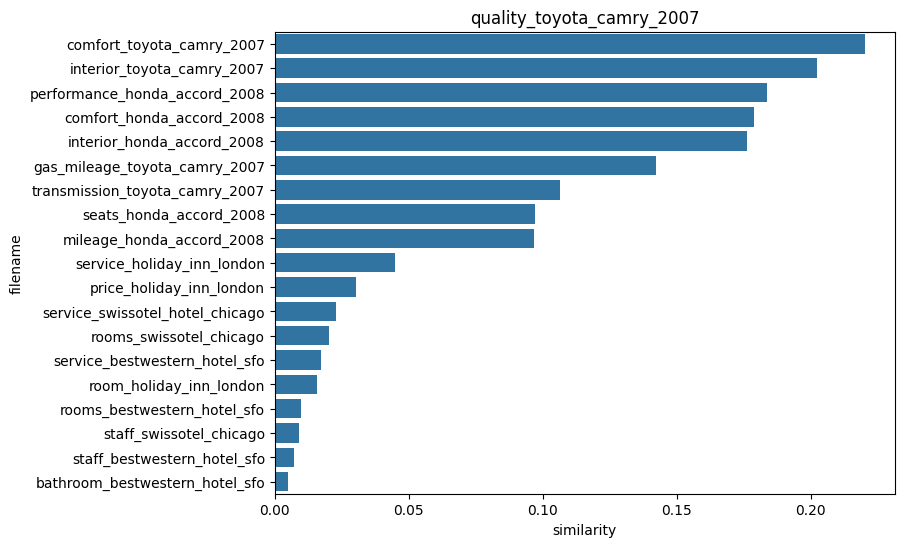

In [62]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

# 1) 첫 번째 문서와 타 문서 간 유사도를 큰 순서로 정렬 (자기 자신 제외)
sorted_index = similarity_pair.argsort()[:, ::-1]
sorted_index = sorted_index[:, 1:]   # 자기 자신(유사도=1) 제외

# 2) 유사도가 큰 순으로 hotel_indexes 재정렬
hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]

# 3) 유사도 값도 큰 순으로 정렬 (자기 자신 제외)
hotel_1_sim_value = np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value = hotel_1_sim_value[1:]

# 4) DataFrame 생성
hotel_1_sim_df = pd.DataFrame({
    "filename": document_df.iloc[hotel_sorted_indexes]["filename"].values,
    "similarity": hotel_1_sim_value
})

print("가장 유사도가 큰 파일명 및 유사도:\n", hotel_1_sim_df.iloc[0])

plt.figure(figsize=(8, 6))
sns.barplot(
    x="similarity",
    y="filename",
    data=hotel_1_sim_df,
    orient="h"
)
plt.title(comparison_docname)
plt.show()

In [64]:
import pandas as pd

train_df = pd.read_csv(
    'ratings_train.txt',
    sep='\t',
    encoding='utf-8'
)

train_df.head(3)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [65]:
train_df['label'].value_counts( )

,count
label,
0,75173
1,74827


In [68]:
import re
import pandas as pd


train_df = train_df.fillna(' ')


train_df['document'] = train_df['document'].apply(
    lambda x: re.sub(r"\d+", " ", x)
)

test_df = pd.read_csv(
    'ratings_test.txt',
    sep='\t',
    encoding='utf-8'
)
test_df = test_df.fillna(' ')

test_df['document'] = test_df['document'].apply(
    lambda x: re.sub(r"\d+", " ", x)
)

# id 칼럼 삭제 수행
train_df.drop('id', axis=1, inplace=True)
test_df.drop('id', axis=1, inplace=True)

In [71]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 22.0 MB/s eta 0:00:00


In [72]:
from konlpy.tag import Twitter
twitter = Twitter()
def tw_tokenizer(text):
  # 입력 인자로 들어온 텍스트를 형태소 단어로 토큰화해 리스트 형태로 반환
  tokens_ko = twitter.morphs(text)
  return tokens_ko

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
# Twitter 객체의 morphs( ) 객체를 이용한 tokenizer를 사용. ngram_range는 (1, 2)
tfidf_vect = TfidfVectorizer(
    tokenizer=tw_tokenizer,
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.9
)

tfidf_matrix_train = tfidf_vect.fit_transform(train_df['document'])
tfidf_matrix_test = tfidf_vect.transform(test_df['document'])

In [81]:
# 로지스틱 회귀를 이용해 감성 분석 분류 수행.
lg_clf = LogisticRegression(random_state=0, solver='liblinear')
# 파라미터 C 최적화를 위해 GridSearchCV를 이용.
params = {'C':[1, 3.5, 4.5, 5.5, 10] }
grid_cv = GridSearchCV(lg_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv.fit(tfidf_matrix_train, train_df['label'])
print(grid_cv.best_params_, round(grid_cv.best_score_, 4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
{'C': 3.5} 0.8498


In [84]:
from sklearn.metrics import accuracy_score
# 학습 데이터를 적용한 TfidfVectorizer를 이용해 테스트 데이터를 TF-IDF 값으로 피처 변환함.
tfidf_matrix_test = tfidf_vect.transform(test_df['document'])
# classifier는 GridSearchCV에서 최적 파라미터로 학습된 classifier를 그대로 이용
best_estimator = grid_cv.best_estimator_
preds = best_estimator.predict(tfidf_matrix_test)
print ('Logistic Regression 정확도: ', accuracy_score(test_df ['label'], preds))

Logistic Regression 정확도:  0.84932
